### Homework 5: NumPy & Matplotlib

In [390]:
import numpy as np
from matplotlib import pyplot as plt 

In [391]:
x = np.linspace(-2,2,100)
y = np.linspace(-2, 2,100)
x_1, y_1 =np.meshgrid(x,y)

In [392]:
x = np.linspace(-2,2,100)
y = np.linspace(-2, 2,100)
x_1, y_1 =np.meshgrid(x,y)

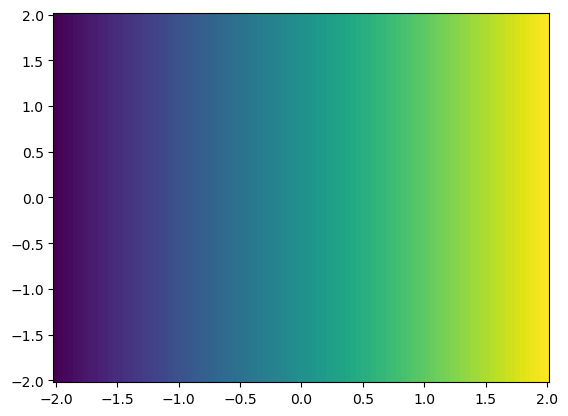

In [393]:
plt.pcolormesh(x, y, x_1)

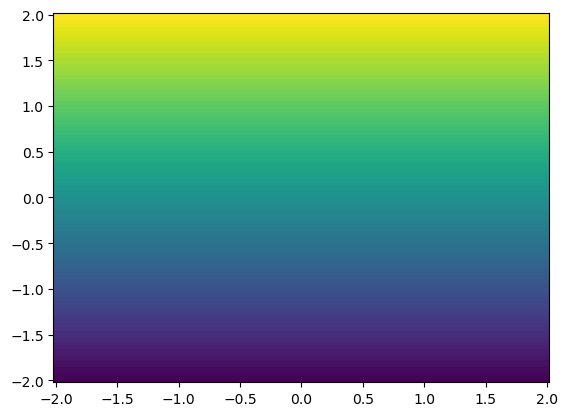

In [394]:
plt.pcolormesh(x,y,y_1)

In [395]:
r = np.sqrt((x_1**2) + (y_1**2))
phi = np.arctan2(y_1, x_1)

In [396]:
print(r)

[[2.82842712 2.80000292 2.77187619 ... 2.77187619 2.80000292 2.82842712]
 [2.80000292 2.77128718 2.74286601 ... 2.74286601 2.77128718 2.80000292]
 [2.77187619 2.74286601 2.71414724 ... 2.71414724 2.74286601 2.77187619]
 ...
 [2.77187619 2.74286601 2.71414724 ... 2.71414724 2.74286601 2.77187619]
 [2.80000292 2.77128718 2.74286601 ... 2.74286601 2.77128718 2.80000292]
 [2.82842712 2.80000292 2.77187619 ... 2.77187619 2.80000292 2.82842712]]


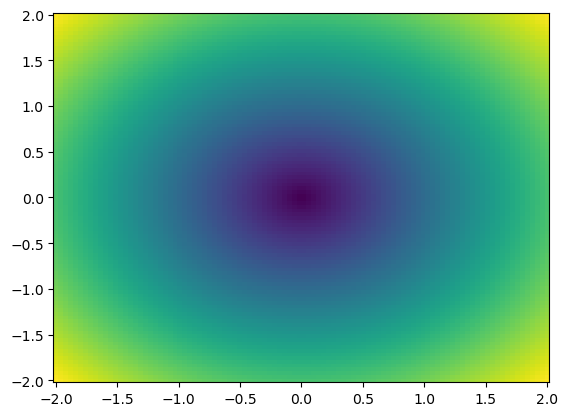

In [397]:
plt.pcolormesh(x, y, r)

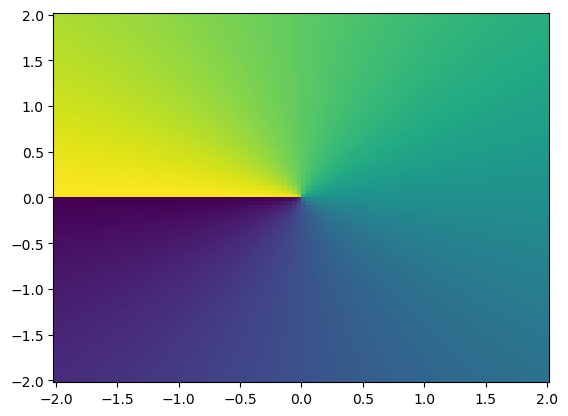

In [398]:
plt.pcolormesh(x,y,phi)

In [399]:
f = np.cos(4*r)**2 + np.sin(4*phi)**2

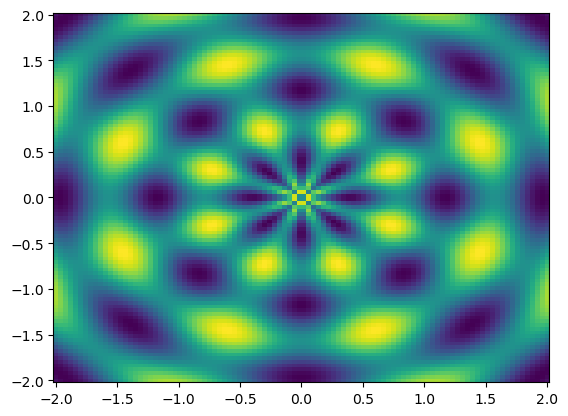

In [400]:
plt.pcolormesh(x,y,f)

## Part 2: ARGO Data

In [228]:
import pooch
url = "https://www.ldeo.columbia.edu/~danielmw/float_data.zip"
files = pooch.retrieve(url, processor=pooch.Unzip(), known_hash="2a703c720302c682f1662181d329c9f22f9f10e1539dc2d6082160a469165009")
files

['/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy',
 '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy',
 '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy',
 '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy',
 '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy',
 '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy',
 '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']

In [229]:
print(files)

['/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/date.npy', '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/T.npy', '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/S.npy', '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/P.npy', '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/levels.npy', '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lon.npy', '/home/ap4825/.cache/pooch/182581396e4937a1fb09550d60cbc382-float_data.zip.unzip/float_data/lat.npy']


In [236]:
date = np.load(files[0])

In [237]:
T = np.load(files[1])

In [238]:
S = np.load(files[2])

In [239]:
P = np.load(files[3])

In [240]:
level = np.load(files[4])

In [241]:
lon = np.load(files[5])

In [242]:
lat= np.load(files[6])

In [243]:
np.shape(lon)

(75,)

In [244]:
np.shape(lat)

(75,)

In [245]:
np.shape(date)

(75,)

In [246]:
np.shape(level)

(78,)

In [248]:
np.shape(T)

(78, 75)

In [249]:
np.shape(S)

(78, 75)

In [250]:
np.shape(P)

(78, 75)

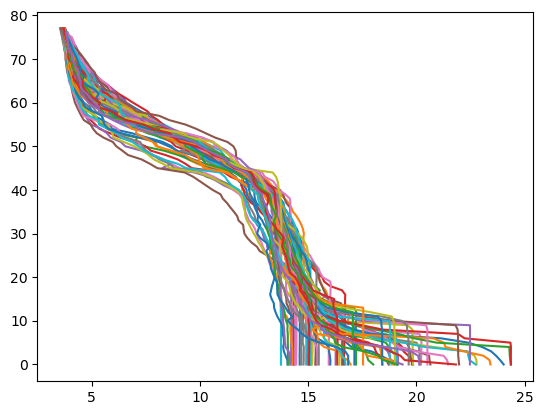

In [280]:
num = np.arange(0,75)

for y in num:
  plt.plot(T[:,y],level)


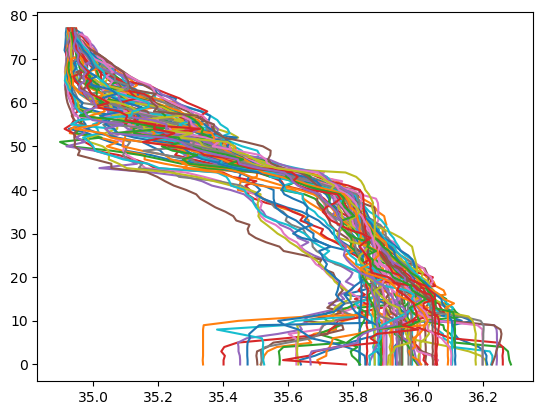

In [282]:
for y in num: 
    plt.plot(S[:,y], level)

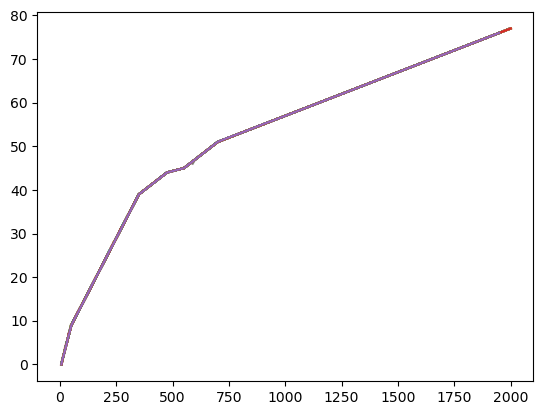

In [283]:
for y in num: 
    plt.plot(P[:,y],level)

In [375]:
num_level = np.arange(0,78)
T_means = [] 
T_sd = []
for y in num_level: 
    T_means.append( np.nanmean(T[y,:]))
    T_sd.append(np.nanstd(T[y, :]))


In [376]:
S_means = [] 
S_sd = []
for y in num_level: 
    S_means.append( np.nanmean(S[y,:]))
    S_sd.append(np.nanstd(S[y,:]))


In [377]:
P_means = [] 
P_sd = []
for y in num_level: 
    P_means.append( np.nanmean(P[y,:]))
    P_sd.append(np.nanstd(P[y:,]))



In [378]:
len(date)


75

<ErrorbarContainer object of 3 artists>

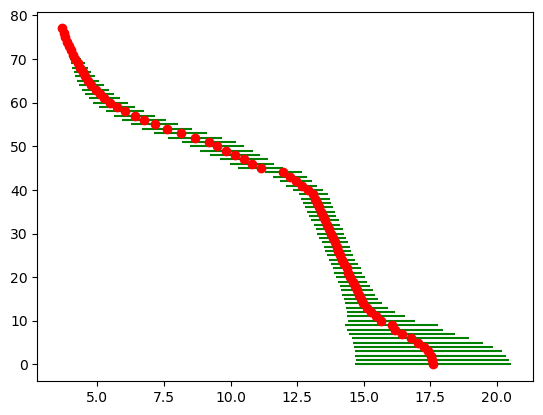

In [380]:
plt.errorbar(T_means, level, xerr=T_sd, fmt='o',yerr=None,color='red',ecolor='green')

<ErrorbarContainer object of 3 artists>

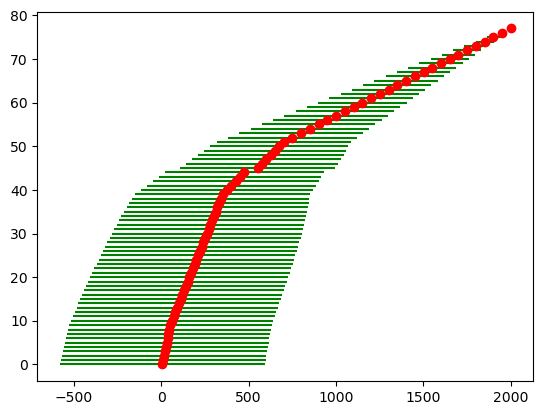

In [381]:
plt.errorbar(P_means, level, xerr=P_sd,fmt='o',yerr=None,color='red',ecolor='green')

<ErrorbarContainer object of 3 artists>

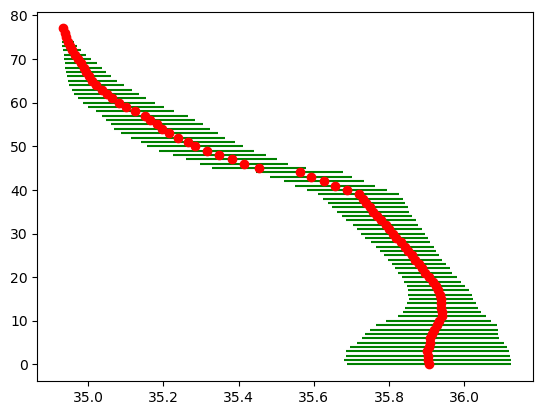

In [382]:
plt.errorbar(S_means, level, xerr=S_sd, fmt='o',yerr=None,color='red',ecolor='green')

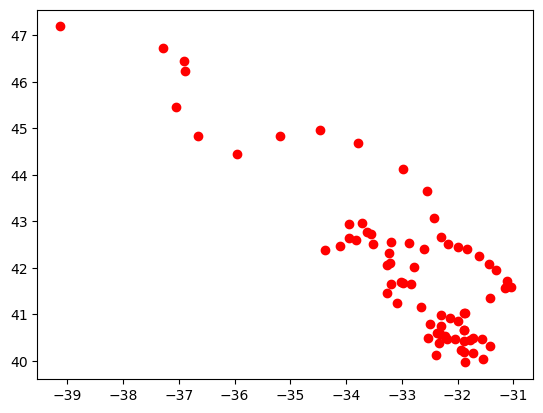

In [385]:
plt.scatter(lon,lat, c='red')